In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlibcolors_v2
plt.style.use('matplotlibrc_v2')

%matplotlib widget


In [59]:
Lk1 = 75
Lk2 = np.array([70, 72, 73, 74, 74.5, 74.75, 74.95, 74.97, 75, 75.02, 75.05, 75.25, 75.5, 76, 77, 78, 80])
f1_Lk = np.array([4.58445, 4.58432, 4.58416, 4.58369, 4.58287, 4.58177, 4.57989, 4.57963, 4.5792, 4.57889, 4.5784, 4.57435, 4.56806, 4.55422, 4.5258, 4.49761, 4.4426])
f2_Lk = np.array([4.74119, 4.67689, 4.6458, 4.61564, 4.60137, 4.59498, 4.59089, 4.59056, 4.5901, 4.58981, 4.5894, 4.58753, 4.58643, 4.58562, 4.58515, 4.58499, 4.58485])
D = np.array([136, 140, 150, 180, 200, 220, 250, 290, 300, 310, 350, 400, 500])
f1_D = np.array([4.5792, 4.58044, 4.58253, 4.58407, 4.58469, 4.58512, 4.58534, 4.58514, 4.58425, 4.58533, 4.58548, 4.58549, 4.58549])
f2_D = np.array([4.5901, 4.58874, 4.58692, 4.58555, 4.58552, 4.58566, 4.5854, 4.5855, 4.5855, 4.5855, 4.5855, 4.5855, 4.58549])
df_D = f2_D-f1_D
swap = 8
kid1 = np.hstack((f1_Lk[:swap], f2_Lk[swap:]))
kid2 = np.hstack((f2_Lk[:swap], f1_Lk[swap:]))

In [60]:
def root(x, a, b):
    return a/np.sqrt(x) + b

def square(x, a, b):
    return (a/(x-b))**2

def exp(x, a, b):
    return a*np.exp(-b*x**2)

In [61]:
popt, _ = curve_fit(root, Lk2, kid2, p0=[1, 0])
pexp, _ = curve_fit(exp, D*1e-3, df_D)
print(pexp)

[  0.40447102 196.9361576 ]


(0.001, 100.0)

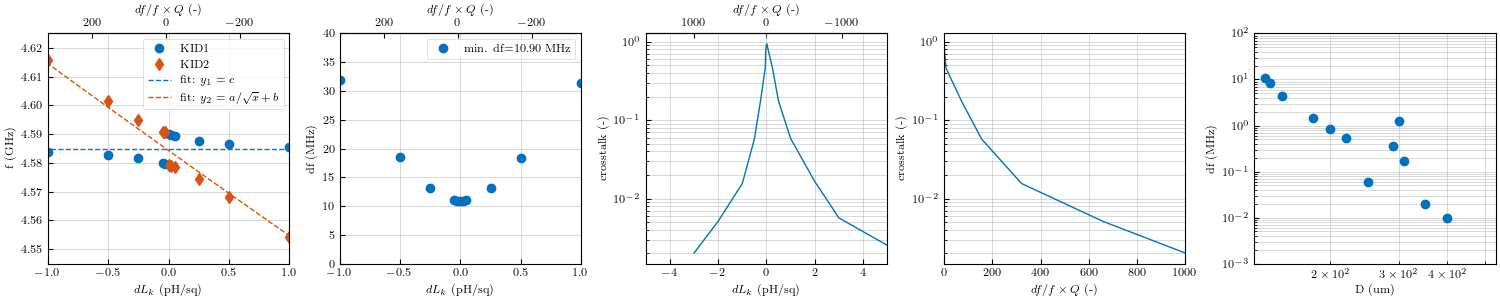

In [62]:
fig, axes = plt.subplot_mosaic('abcde', figsize=(15, 3), constrained_layout=True)  
ax = axes['a']
avg = np.mean(kid1)
y1 = avg * np.ones(kid1.shape)
y2 = root(Lk2, *popt)
Q = 50e3
df_f = (y2-y1)/y1
dLk = Lk2-Lk1
ax.plot(dLk, kid1, 'o ', label='KID1')
ax.plot(dLk, kid2, 'd ', label='KID2')
ax2 = ax.secondary_xaxis('top', functions=(lambda x: (root(x+Lk1, *popt)-avg)/avg*Q, lambda x: (square(x/Q*avg+avg, *popt)-Lk1)))
ax2.set_xlabel('$df/f\\times Q$ (-)')
ax.set_xlabel('$dL_k$ (pH/sq)')
ax.set_ylabel('f (GHz)')
ax.plot(dLk, y1, ls='--', c='b', label='fit: $y_1=c$')
ax.plot(dLk, y2, ls='--', c='o', label='fit: $y_2=a/\\sqrt{x}+b$')
ax.set_xlim([-1, 1])
ax.set_ylim([-.04, 0.04]+avg)
ax.legend()
ax = axes['b']
ax.plot(dLk, (f2_Lk-f1_Lk)*1e3, marker='o', ls='None', label='min. df=%.2f MHz' % np.min(np.abs(f2_Lk-f1_Lk)*1e3))
# ax.plot(dLk, np.abs(y1-y2)*1e3, ls='--', c='k', label='y1-y2')
ax2 = ax.secondary_xaxis('top', functions=(lambda x: (root(x+Lk1, *popt)-avg)/avg*Q, lambda x: (square(x/Q*avg+avg, *popt)-Lk1)))
ax2.set_xlabel('$df/f\\times Q$ (-)')
ax.set_xlabel('$dL_k$ (pH/sq)')
ax.set_ylabel('df (MHz)')
ax.set_xlim([-1, 1])
ax.set_ylim([0, 40])
ax.legend()
ax = axes['c']
ct = np.abs(np.diff(kid1))/np.abs(np.diff(kid2))
lw = (root(dLk+Lk1, *popt)-avg)/avg*Q
ax2 = ax.secondary_xaxis('top', functions=(lambda x: (root(x+Lk1, *popt)-avg)/avg*Q, lambda x: (square(x/Q*avg+avg, *popt)-Lk1)))
ax2.set_xlabel('$df/f\\times Q$ (-)')
ax.semilogy(dLk[1:], ct)
ax.set_xlim([-5, 5])
ax.set_xlabel('$dL_k$ (pH/sq)')
ax.set_ylabel('crosstalk (-)')
ax = axes['d']
ax.semilogy(lw[1:], ct)
ax.set_xlim([0, 1000])
# ax.set_ylim([1e-3, 1e0])
ax.set_xlabel('$df/f\\times Q$ (-)')
ax.set_ylabel('crosstalk (-)')
ax = axes['e']
ax.loglog(D, df_D*1e3, marker='o', ls='None')
ax.set_xlabel('D (um)')
ax.set_ylabel('df (MHz)')
# ax.set_xlim([150, 200])
ax.set_ylim([1e-3, 1e2])
# _ = ax.set_xticks([150, 160, 170, 180, 190, 200])
# _ = ax.set_xticklabels([150, 160, 170, 180, 190, 200])

In [63]:
def S21(S, X):
    R = (S+4*X**2)/(1+4*X**2)
    I = 2*X*(1-S)/(1+4*X**2)
    return R + 1j*I

def abs_S21_bisi(S, X):
    return 1-(1-S**2)/(1+4*X**2)

def ang_S21_bisi(X):
    return np.arctan(4*X/(X**2-1))

In [32]:
dX = 2
X = np.linspace(-10, 10, 1000)
X1 = X+dX/2
X2 = X-dX/2
S = 10**(-2)
Z1 = S21(S, X1)
Z2 = S21(S, X2)
Z = Z1*Z2
mag = np.abs(Z)
phase = np.angle(Z)
grad_phase = np.gradient(phase, X)

phase_bisigello = np.arctan(4*X/(X**2-1))
grad_bisigello = 4*(4*X**2+1)/(16*X**2+(4*X**2-1)**2)
mag_bisigello = (S**2+4*X**2)/(1+4*X**2)
dphase_dX = np.gradient(phase_bisigello, X)

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(12, 5))
ax[0, 0].plot(Z1.real-(1+S)/2, Z1.imag)
ax[0, 1].plot(X1, np.abs(Z1)**2)
ax[0, 1].plot(X1, abs_S21_bisi(S, X1), ls='--')
ax[0, 2].plot(X1, np.angle(Z1))
ax[1, 0].plot(Z.real-(1+S)/2, Z.imag)
ax[1, 1].plot(X, mag)
ax[1, 2].plot(X, phase)
ax[1, 2].plot(X1, ang_S21_bisi(X1), ls='--')
# ax[1, 2].plot(X, phase, label='phase')
# ax[1, 2].plot(X, phase_bisigello, label='bisi')
# ax[1, 2].plot(X, grad_phase, label='grad phase')
# ax[1, 2].plot(X, grad_bisigello, label='grad bisi')
# ax[1, 2].plot(X, -dphase_dX, label='dphasedx')
# ax[1, 2].legend()


In [ ]:
fig, ax = plt.subplots()
ax.plot(Z1.real, Z1.imag)
ax.plot(((Z1-1)*-1j+1).real, ((Z1-1)*-1j+1).imag)
ax.set_aspect('equal')

In [ ]:
np.rad2deg(np.arctan(2*5e4*2e-4))

In [ ]:
fig, ax = plt.subplots(constrained_layout=True, figsize=(3,3))
dw_w = np.logspace(-5, -2)
phi = np.rad2deg(np.arctan(2*5e4*dw_w))
ax.semilogx(dw_w, phi)
ax.set_xlabel('dw/w')
ax.set_ylabel('Phase (deg)')
print(np.rad2deg(np.arctan(2*5e4*1e-4)))
ax.grid()